# Angriness Predictor v2 — Semi-Supervised (7 Behavioral + ELO)

This notebook documents the **v2 production pipeline** for the Angriness (Tilt) Predictor.

**Key change from v1:** Dropped all non-behavioral features (time control, synthetic IoT data). The model now uses **7 behavioral tilt features + ELO** (8 total). ELO provides skill context — the "weight" of a blunder depends on rating (a 900 ELO player making 3 blunders is normal; a 2000+ ELO player making 3 blunders strongly indicates tilt). The synthetic IoT features (sleep, water, temperature, CO2, light) were randomly generated and added noise, not signal.

**Semi-supervised approach:**
1. **Stage 1 (IF):** Isolation Forest trained on 8 scaled features → generates pseudo-labels (angriness 1-5)
2. **Stage 2 (RF):** Random Forest Classifier trained on 8 **unscaled** features using IF labels → production model

RF is tree-based and scale-invariant, so training on unscaled features eliminates the need for a scaler at inference.

**Pipeline steps:**
1. **Gather** — Load and validate the training dataset
2. **Features** — Select 8 feature columns, IQR outlier removal, scale for IF, boxplot quality check
3. **Train** — Stage 1: IF → pseudo-labels; Stage 2: RF on unscaled features
4. **Evaluate** — Accuracy/F1, proxy R², Spearman, overfitting diagnostics

In [22]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import pearsonr, spearmanr

TRAINER_DIR = Path.cwd().resolve().parent
RAW_DIR = TRAINER_DIR / "data" / "raw"
LEGACY_DIR = TRAINER_DIR / "data" / "legacy"
PLOT_DIR = Path.cwd() / "plots"
PLOT_DIR.mkdir(exist_ok=True)

print(f"Trainer root: {TRAINER_DIR}")
print(f"Raw data:     {RAW_DIR}")

Trainer root: C:\swe_repos\my-portfolio-and-vps-repos\Chess-Assistance\machine_learning\trainers\trainer-angriness-predictor
Raw data:     C:\swe_repos\my-portfolio-and-vps-repos\Chess-Assistance\machine_learning\trainers\trainer-angriness-predictor\data\raw


## Step 1: Data Gathering

Load the training dataset and validate its structure. The dataset contains **25,249 games** from **~12,300 players** across balanced ELO brackets (800–3400+).

In [23]:
DIVERSE_CSV = RAW_DIR / "angriness_dataset_diverse.csv"
ORIGINAL_CSV = LEGACY_DIR / "angriness_dataset.csv"

csv_path = DIVERSE_CSV if DIVERSE_CSV.exists() else ORIGINAL_CSV
if not csv_path.exists():
    raise FileNotFoundError(f"No dataset found. Expected {DIVERSE_CSV} or {ORIGINAL_CSV}")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.name}")
print(f"  Shape: {df.shape}")
print(f"  Unique players: {df['username'].nunique()}")
df.head()

Loaded: angriness_dataset_diverse.csv
  Shape: (25249, 28)
  Unique players: 12301


,sleep_duration,consecutive_losses,awaken_duration,avg_tpm,move_cnt,inaccuracy_cnt_player,mistake_cnt_player,blunder_cnt_player,elo,elo_diff,...,elo_gap,move_cnt_player,avg_tpm_seconds_player,consecutive_losses_pregame,acpl_player,accuracy_player,avg_ppm,avg_celsius,water_intake_ml,avg_lux
0,7.80,0,1.58,13.6555,83,7.0,1.0,3.0,1011,8.0,...,8.0,41,27.6440,0,114.0,0.0,1313.91,22.10,1050,162.16
1,8.06,3,2.68,16.3612,65,0.0,1.0,0.0,1035,2.0,...,2.0,33,32.2266,3,35.0,19.3,1382.90,22.10,500,799.07
2,5.52,0,3.46,4.8241,74,4.0,4.0,2.0,1172,-134.0,...,-142.0,37,9.6482,0,91.0,0.0,1621.77,25.59,329,327.79
3,6.52,0,1.91,7.3261,75,2.0,1.0,1.0,1180,50.0,...,49.0,38,14.4594,0,56.0,5.8,1617.90,27.08,960,134.71
4,5.90,0,0.59,14.3966,59,2.0,0.0,1.0,1177,-126.0,...,-133.0,30,28.3133,0,28.0,27.3,1598.63,27.13,660,602.97


In [24]:
ANALYSIS_COLUMNS = [
    "acpl_player", "blunder_cnt_player", "mistake_cnt_player",
    "inaccuracy_cnt_player",
]

before = len(df)
df = df.dropna(subset=ANALYSIS_COLUMNS)
dropped = before - len(df)
print(f"Dropped {dropped} rows with null analysis -> {len(df)} remaining")

Dropped 0 rows with null analysis -> 25249 remaining


## Step 2: Feature Selection

Select **7 behavioral tilt features + ELO** (8 total). ELO is included because the "weight" of a blunder depends on skill level — a 900 ELO player making 3 blunders is normal, while a 2000+ ELO player making 3 blunders strongly indicates tilt.

| Feature | Description |
|---|---|
| `consecutive_losses_pregame` | Loss streak before this game |
| `avg_tpm_seconds_player` | Average time per move (seconds) |
| `blunder_cnt_player` | Number of blunders |
| `mistake_cnt_player` | Number of mistakes |
| `inaccuracy_cnt_player` | Number of inaccuracies |
| `acpl_player` | Average centipawn loss |
| `accuracy_player` | Move accuracy percentage |
| `elo` | Player's rating (skill context) |

**Dropped (14 features):**
- ELO-relative (3): elo_diff, opponent_elo, elo_gap — opponent-relative, not player skill context
- Time control (2): time_control_initial, time_control_increment
- Move counts (2): move_cnt, move_cnt_player
- Synthetic IoT (6): sleep_duration, awaken_duration, avg_ppm, avg_celsius, water_intake_ml, avg_lux
- Categorical (1): is_black

In [ ]:
BEHAVIORAL_FEATURES = [
    "consecutive_losses_pregame",
    "avg_tpm_seconds_player",
    "blunder_cnt_player",
    "mistake_cnt_player",
    "inaccuracy_cnt_player",
    "acpl_player",
    "accuracy_player",
    "elo",
]

df_raw = df[BEHAVIORAL_FEATURES].copy()

for col in df_raw.columns:
    if df_raw[col].isnull().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

print(f"Selected {len(BEHAVIORAL_FEATURES)} features (7 behavioral + ELO context)")
print(f"Shape: {df_raw.shape}")
print(f"Nulls: {df_raw.isnull().sum().sum()}")
df_raw.describe().round(2)

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22", "#34495e"]

for i, col in enumerate(BEHAVIORAL_FEATURES):
    ax = axes[i]
    bp = ax.boxplot(df_raw[col].values, patch_artist=True, widths=0.6)
    bp["boxes"][0].set_facecolor(colors[i])
    bp["boxes"][0].set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Value")
    median = df_raw[col].median()
    mean = df_raw[col].mean()
    ax.text(1.15, median, f"med={median:.1f}", va="center", fontsize=8, color="#2c3e50")
    ax.text(1.15, mean, f"avg={mean:.1f}", va="center", fontsize=8, color="#e74c3c")

fig.suptitle("BEFORE Outlier Removal — Feature Distributions", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOT_DIR / "behavioral_distributions_before.png", dpi=150)
plt.show()

### Outlier Removal (IQR × 1.5, P99 fallback)

Remove rows where **any** of the 8 features falls outside the interquartile range (Q1 - 1.5×IQR, Q3 + 1.5×IQR). For **zero-inflated features** where IQR=0 (e.g., `consecutive_losses_pregame` — most values are 0), fall back to the **99th percentile** as the upper bound. Standard losing streaks are 3-5 games; anything well beyond that is an outlier.

In [ ]:
IQR_MULTIPLIER = 1.5

mask = pd.Series(True, index=df_raw.index)
print(f"Outlier removal (IQR × {IQR_MULTIPLIER}):\n")
print(f"  {'Feature':<30} {'Lower':>8} {'Upper':>8} {'Outliers':>8}")
print(f"  {'-'*30} {'-'*8} {'-'*8} {'-'*8}")

for col in BEHAVIORAL_FEATURES:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        upper = df_raw[col].quantile(0.99)
        if upper == 0:
            print(f"  {col:<30} {'IQR=0, P99=0 — skipped':>28}")
            continue
        col_mask = df_raw[col] <= upper
        flagged = (~col_mask).sum()
        print(f"  {col:<30} {'—':>8} {upper:>8.2f} {flagged:>8}  (P99 fallback)")
        mask &= col_mask
        continue
    lower = q1 - IQR_MULTIPLIER * iqr
    upper = q3 + IQR_MULTIPLIER * iqr
    col_mask = (df_raw[col] >= lower) & (df_raw[col] <= upper)
    flagged = (~col_mask).sum()
    print(f"  {col:<30} {lower:>8.2f} {upper:>8.2f} {flagged:>8}")
    mask &= col_mask

n_removed = (~mask).sum()
print(f"\n  Total rows removed: {n_removed} ({n_removed / len(df_raw):.1%})")
print(f"  Rows kept: {mask.sum()} ({mask.sum() / len(df_raw):.1%})")

df_raw = df_raw.loc[mask].reset_index(drop=True)
df = df.loc[mask].reset_index(drop=True)
print(f"\n  Cleaned shape: {df_raw.shape}")

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22", "#34495e"]

for i, col in enumerate(BEHAVIORAL_FEATURES):
    ax = axes[i]
    bp = ax.boxplot(df_raw[col].values, patch_artist=True, widths=0.6)
    bp["boxes"][0].set_facecolor(colors[i])
    bp["boxes"][0].set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Value")
    median = df_raw[col].median()
    mean = df_raw[col].mean()
    ax.text(1.15, median, f"med={median:.1f}", va="center", fontsize=8, color="#2c3e50")
    ax.text(1.15, mean, f"avg={mean:.1f}", va="center", fontsize=8, color="#e74c3c")

fig.suptitle("AFTER Outlier Removal — Feature Distributions", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOT_DIR / "behavioral_distributions_after.png", dpi=150)
plt.show()

print(f"\nCleaned stats:")
df_raw.describe().round(2)

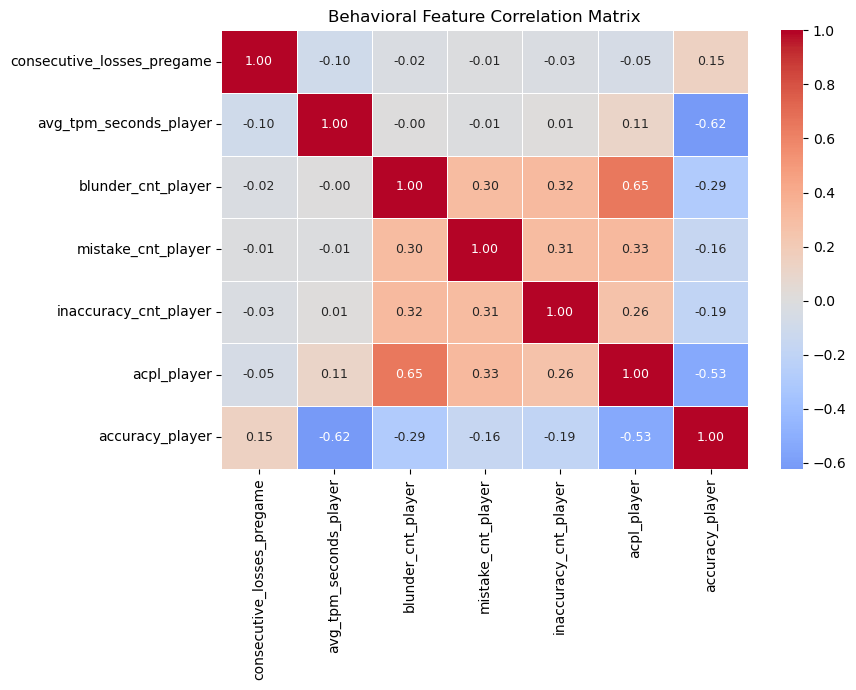

In [29]:
corr = df_raw.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 9}, linewidths=0.5)
ax.set_title("Behavioral Feature Correlation Matrix")
fig.tight_layout()
fig.savefig(PLOT_DIR / "behavioral_correlation.png", dpi=150)
plt.show()

In [30]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_raw),
    columns=BEHAVIORAL_FEATURES,
)

print(f"Scaled for IF: {df_scaled.shape}")
print(f"Note: Scaling is only needed for IF label generation.")
print(f"RF is trained on unscaled features and doesn't need scaling at inference.")

Scaled for IF: (23014, 7)
Note: Scaling is only needed for IF label generation.
RF is trained on unscaled features and doesn't need scaling at inference.


## Step 3: Training (Semi-Supervised)

### Stage 1: Isolation Forest (Label Generation)
IF trained on **8 scaled** features → anomaly scores → percentile-binned into angriness 1-5.

### Stage 2: Random Forest Classifier
RF trained on **8 unscaled** features using IF pseudo-labels. Since RF is tree-based, it's invariant to monotonic transformations — no scaler needed at inference.

**Data Split**: 64:16:20 (train:val:test) via two-stage 80:20.

In [31]:
indices = np.arange(len(df_scaled))
trainval_idx, test_idx = train_test_split(indices, test_size=0.20, random_state=42)
train_idx, val_idx = train_test_split(trainval_idx, test_size=0.20, random_state=42)

# Scaled splits (for IF)
scaled_train = df_scaled.iloc[train_idx].reset_index(drop=True)
scaled_val = df_scaled.iloc[val_idx].reset_index(drop=True)
scaled_test = df_scaled.iloc[test_idx].reset_index(drop=True)

# Unscaled splits (for RF and evaluation)
raw_train = df_raw.iloc[train_idx].reset_index(drop=True)
raw_val = df_raw.iloc[val_idx].reset_index(drop=True)
raw_test = df_raw.iloc[test_idx].reset_index(drop=True)

print(f"Split: {len(scaled_train)} train / {len(scaled_val)} val / {len(scaled_test)} test ")
print(f"  ({len(scaled_train)/len(df_scaled):.0%}/{len(scaled_val)/len(df_scaled):.0%}/{len(scaled_test)/len(df_scaled):.0%})")

Split: 14728 train / 3683 val / 4603 test 
  (64%/16%/20%)


In [32]:
# Stage 1: Isolation Forest
if_model = IsolationForest(
    contamination=0.03,
    n_estimators=200,
    max_features=0.75,
    random_state=42,
)

if_model.fit(scaled_train.values)

scores = if_model.decision_function(scaled_train.values)
n_anomalies = (if_model.predict(scaled_train.values) == -1).sum()
print(f"Stage 1: Isolation Forest trained on {len(BEHAVIORAL_FEATURES)} scaled features")
print(f"Anomalies: {n_anomalies} / {len(scaled_train)} ({n_anomalies / len(scaled_train):.1%})")

Stage 1: Isolation Forest trained on 7 scaled features
Anomalies: 442 / 14728 (3.0%)


In [33]:
PERCENTILE_EDGES = [0, 10, 35, 65, 90, 100]


def score_to_angriness(score, bin_edges):
    for i in range(len(bin_edges) - 1):
        if score <= bin_edges[i + 1]:
            return 5 - i
    return 1


bin_edges = [float(np.percentile(scores, p)) for p in PERCENTILE_EDGES]
print(f"Percentiles: {PERCENTILE_EDGES}")
print(f"Bin edges:   {[round(e, 4) for e in bin_edges]}")

y_train = np.array([score_to_angriness(s, bin_edges) for s in scores])

print(f"\nAngriness distribution (IF pseudo-labels):")
for level in range(1, 6):
    count = (y_train == level).sum()
    print(f"  Level {level}: {count:,} ({count / len(y_train):.1%})")

Percentiles: [0, 10, 35, 65, 90, 100]
Bin edges:   [-0.1087, 0.0355, 0.088, 0.1202, 0.1465, 0.1745]

Angriness distribution (IF pseudo-labels):
  Level 1: 1,473 (10.0%)
  Level 2: 3,682 (25.0%)
  Level 3: 4,418 (30.0%)
  Level 4: 3,682 (25.0%)
  Level 5: 1,473 (10.0%)


In [34]:
# Stage 2: Random Forest on UNSCALED features
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(raw_train.values, y_train)

rf_pred_train = rf_model.predict(raw_train.values)
rf_accuracy = (rf_pred_train == y_train).mean()
print(f"Stage 2: Random Forest trained on {len(BEHAVIORAL_FEATURES)} unscaled features")
print(f"Train accuracy (vs IF labels): {rf_accuracy:.4f}")

Stage 2: Random Forest trained on 7 unscaled features
Train accuracy (vs IF labels): 1.0000


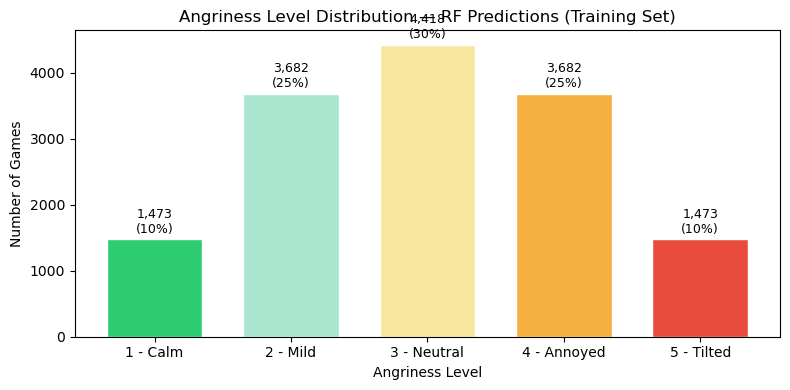

In [35]:
level_counts = pd.Series(rf_pred_train).value_counts().sort_index()
level_labels = {1: "Calm", 2: "Mild", 3: "Neutral", 4: "Annoyed", 5: "Tilted"}
level_colors = ["#2ecc71", "#a8e6cf", "#f9e79f", "#f5b041", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(level_counts.index, level_counts.values, color=level_colors, edgecolor="white", width=0.7)
for bar, count in zip(bars, level_counts.values):
    pct = count / len(rf_pred_train) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{count:,}\n({pct:.0f}%)", ha="center", fontsize=9)
ax.set_xticks(level_counts.index)
ax.set_xticklabels([f"{lvl} - {level_labels[lvl]}" for lvl in level_counts.index])
ax.set_xlabel("Angriness Level")
ax.set_ylabel("Number of Games")
ax.set_title("Angriness Level Distribution — RF Predictions (Training Set)")
fig.tight_layout()
fig.savefig(PLOT_DIR / "v2_angriness_distribution.png", dpi=150)
plt.show()

In [36]:
tilt_cols = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
raw_check = raw_train.copy()
raw_check["_angriness"] = rf_pred_train

sanity = raw_check.groupby("_angriness")[tilt_cols].mean().round(2)
sanity.index.name = "Angriness"
sanity.columns = ["ACPL", "Blunders", "Consecutive Losses"]
print("Sanity check — unscaled feature means by angriness level (train set):\n")
sanity

Sanity check — unscaled feature means by angriness level (train set):



,ACPL,Blunders,Consecutive Losses
Angriness,,,
1,50.85,1.50,0.00
2,44.27,1.28,0.03
3,44.72,1.44,0.18
4,55.28,2.11,0.52
5,70.53,3.12,1.18


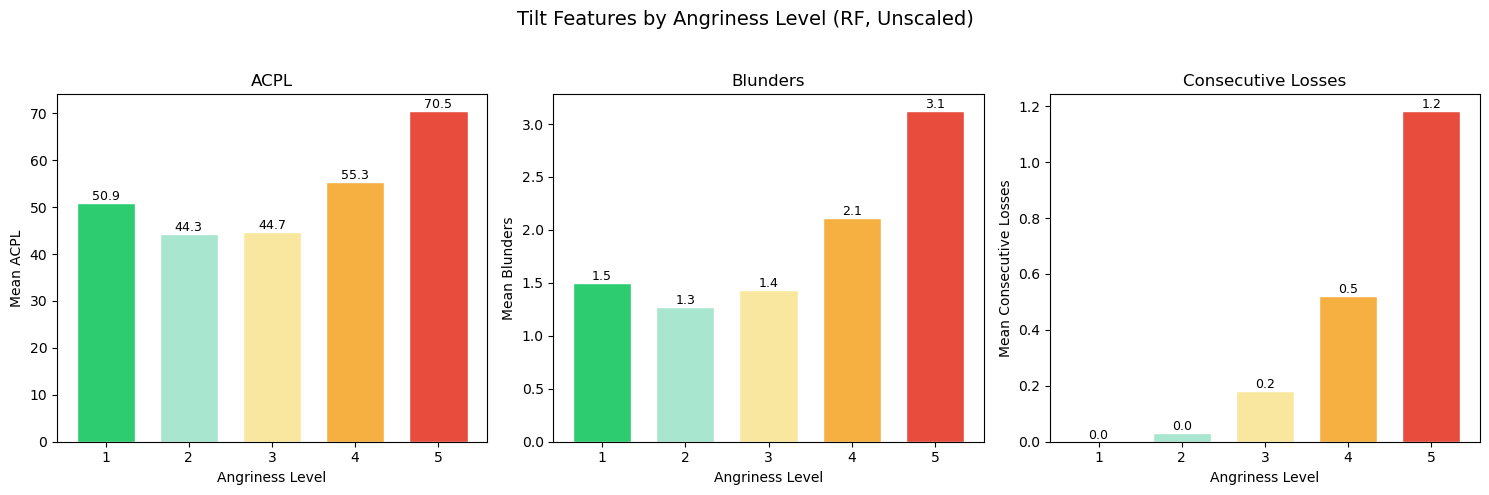

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, [("acpl_player", "ACPL"), ("blunder_cnt_player", "Blunders"), ("consecutive_losses_pregame", "Consecutive Losses")]):
    means = raw_check.groupby("_angriness")[col].mean()
    bars = ax.bar(means.index, means.values, color=level_colors, edgecolor="white", width=0.7)
    ax.set_xlabel("Angriness Level")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(label)
    ax.set_xticks(means.index)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Tilt Features by Angriness Level (RF, Unscaled)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOT_DIR / "v2_sanity_check_by_level.png", dpi=150)
plt.show()

## Step 4: Evaluation

Evaluate the semi-supervised RF model on held-out test data:
- **Accuracy / F1** — how well RF reproduces IF labels on unseen data
- **Proxy R²** — correlation between predicted class and composite tilt signal
- **Spearman ρ** — rank correlation with individual tilt features
- **Validation checks** — tilted games (4-5) should have higher ACPL, more blunders, more losses than calm (1-2)

In [38]:
rf_pred_test = rf_model.predict(raw_test.values)

# IF labels on test set for accuracy
if_scores_test = if_model.decision_function(scaled_test.values)
y_test_if = np.array([score_to_angriness(s, bin_edges) for s in if_scores_test])
test_acc = accuracy_score(y_test_if, rf_pred_test)
test_f1 = f1_score(y_test_if, rf_pred_test, average="weighted")
print(f"Test accuracy (vs IF labels): {test_acc:.4f}")
print(f"Test F1 (weighted):           {test_f1:.4f}")

raw = raw_test.copy()
raw["_angriness"] = rf_pred_test

per_level = {}
for level in range(1, 6):
    mask = raw["_angriness"] == level
    subset = raw.loc[mask]
    per_level[str(level)] = {
        "count": int(mask.sum()),
        "mean_acpl": round(float(subset["acpl_player"].mean()), 2) if len(subset) > 0 else None,
        "mean_blunders": round(float(subset["blunder_cnt_player"].mean()), 2) if len(subset) > 0 else None,
        "mean_cons_losses": round(float(subset["consecutive_losses_pregame"].mean()), 2) if len(subset) > 0 else None,
    }

print(f"\nTest set: {len(raw_test)} games\n")
pd.DataFrame(per_level).T

Test accuracy (vs IF labels): 0.8792
Test F1 (weighted):           0.8791

Test set: 4603 games



,count,mean_acpl,mean_blunders,mean_cons_losses
1,457.0,49.73,1.46,0.00
2,1117.0,44.09,1.31,0.03
3,1424.0,43.34,1.36,0.18
4,1192.0,55.79,2.13,0.53
5,413.0,69.87,3.23,1.26


In [39]:
calm = raw[raw["_angriness"].isin([1, 2])]
tilted = raw[raw["_angriness"].isin([4, 5])]

checks = {
    "ACPL higher when tilted": tilted["acpl_player"].mean() > calm["acpl_player"].mean(),
    "Blunders higher when tilted": tilted["blunder_cnt_player"].mean() > calm["blunder_cnt_player"].mean(),
    "Consecutive losses higher when tilted": tilted["consecutive_losses_pregame"].mean() > calm["consecutive_losses_pregame"].mean(),
}

all_pass = all(checks.values())
print(f"Validation: {'PASS' if all_pass else 'FAIL'}\n")
for check, result in checks.items():
    print(f"  {'PASS' if result else 'FAIL'} — {check}")

Validation: PASS

  PASS — ACPL higher when tilted
  PASS — Blunders higher when tilted
  PASS — Consecutive losses higher when tilted


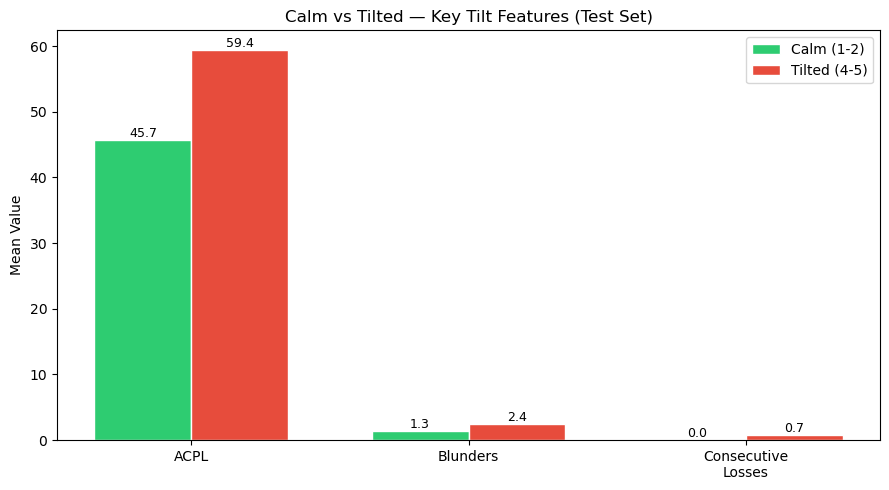

In [40]:
compare_cols = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
compare_labels = ["ACPL", "Blunders", "Consecutive\nLosses"]

calm_means = calm[compare_cols].mean()
tilted_means = tilted[compare_cols].mean()

x = np.arange(len(compare_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, calm_means.values, width, label="Calm (1-2)", color="#2ecc71", edgecolor="white")
bars2 = ax.bar(x + width / 2, tilted_means.values, width, label="Tilted (4-5)", color="#e74c3c", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(compare_labels)
ax.set_ylabel("Mean Value")
ax.set_title("Calm vs Tilted — Key Tilt Features (Test Set)")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "v2_calm_vs_tilted.png", dpi=150)
plt.show()

### Overfitting Diagnostics: Train vs Val vs Test

- **Accuracy / F1** — RF achieves ~100% on train (by design); val vs test gap indicates generalization
- **Proxy R²** — Pearson r² between predicted class and composite tilt
- **Spearman ρ** — Rank correlation with individual tilt features

In [41]:
COMPOSITE_COLS = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
SHORT_NAMES = {"acpl_player": "ACPL", "blunder_cnt_player": "Blunders", "consecutive_losses_pregame": "ConsLoss"}


def compute_composite_tilt(raw_df):
    components = []
    for c in COMPOSITE_COLS:
        vals = raw_df[c].values.astype(float)
        vmin, vmax = vals.min(), vals.max()
        components.append((vals - vmin) / (vmax - vmin + 1e-9))
    return np.mean(components, axis=0)


def evaluate_split(name, raw_df, scaled_df, rf_mdl, if_mdl, edges):
    pred = rf_mdl.predict(raw_df.values)
    if_scores = if_mdl.decision_function(scaled_df.values)
    y_if = np.array([score_to_angriness(s, edges) for s in if_scores])
    acc = round(float(accuracy_score(y_if, pred)), 4)
    f1 = round(float(f1_score(y_if, pred, average="weighted")), 4)

    composite = compute_composite_tilt(raw_df)
    r, _ = pearsonr(pred.astype(float), composite)
    proxy_r2 = round(float(r ** 2), 4)

    spearman = {}
    for col in COMPOSITE_COLS:
        corr, _ = spearmanr(pred.astype(float), raw_df[col].values)
        spearman[col] = round(float(corr), 4)

    return {"name": name, "n": len(raw_df), "accuracy": acc, "f1": f1, "proxy_r2": proxy_r2, "spearman": spearman}


diag_results = []
for name, raw_split, scaled_split in [
    ("train", raw_train, scaled_train),
    ("val", raw_val, scaled_val),
    ("test", raw_test, scaled_test),
]:
    diag_results.append(evaluate_split(name, raw_split, scaled_split, rf_model, if_model, bin_edges))

print("Diagnostics computed for all 3 splits.")

Diagnostics computed for all 3 splits.


In [42]:
R2_GAP_THRESHOLD = 0.05

print("=== Train vs Val vs Test Comparison ===\n")
header = f"{'Split':>6}  {'N':>6}  {'Accuracy':>8}  {'F1':>6}  {'Proxy R2':>8}"
for col in COMPOSITE_COLS:
    header += f"  {SHORT_NAMES[col] + ' rho':>12}"
print(header)
print("-" * len(header))

for r in diag_results:
    row = f"{r['name']:>6}  {r['n']:>6}  {r['accuracy']:>8.4f}  {r['f1']:>6.4f}  {r['proxy_r2']:>8.4f}"
    for col in COMPOSITE_COLS:
        row += f"  {r['spearman'][col]:>12.4f}"
    print(row)

val_r = next(r for r in diag_results if r['name'] == 'val')
test_r = next(r for r in diag_results if r['name'] == 'test')
train_r = next(r for r in diag_results if r['name'] == 'train')
r2_gap = train_r['proxy_r2'] - test_r['proxy_r2']
acc_gap = val_r['accuracy'] - test_r['accuracy']

issues = []
if r2_gap > R2_GAP_THRESHOLD:
    issues.append(f"R2 gap = {r2_gap:.4f}")
if abs(acc_gap) > R2_GAP_THRESHOLD:
    issues.append(f"Accuracy gap (val vs test) = {acc_gap:.4f}")

print(f"\n{'=' * 50}")
if issues:
    print("POSSIBLE OVERFITTING DETECTED:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("NO OVERFITTING DETECTED")
    print(f"  R2 gap:                     {r2_gap:.4f} (threshold: {R2_GAP_THRESHOLD})")
    print(f"  Accuracy gap (val vs test): {acc_gap:.4f} (threshold: {R2_GAP_THRESHOLD})")

=== Train vs Val vs Test Comparison ===

 Split       N  Accuracy      F1  Proxy R2      ACPL rho  Blunders rho  ConsLoss rho
------------------------------------------------------------------------------------
 train   14728    1.0000  1.0000    0.1041        0.1506        0.2110        0.4334
   val    3683    0.8887  0.8887    0.1005        0.1557        0.2034        0.4395
  test    4603    0.8792  0.8791    0.1271        0.1535        0.2135        0.4517

NO OVERFITTING DETECTED
  R2 gap:                     -0.0230 (threshold: 0.05)
  Accuracy gap (val vs test): 0.0095 (threshold: 0.05)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
split_names = [r["name"] for r in diag_results]
colors_split = ["#3498db", "#f39c12", "#e74c3c"]

r2_values = [r["proxy_r2"] for r in diag_results]
axes[0].bar(split_names, r2_values, color=colors_split, edgecolor="white")
axes[0].set_ylabel("Proxy R²")
axes[0].set_title("Proxy R² by Split")
for i, v in enumerate(r2_values):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)

x = np.arange(len(COMPOSITE_COLS))
width = 0.25
for i, r in enumerate(diag_results):
    rhos = [r["spearman"][col] for col in COMPOSITE_COLS]
    axes[1].bar(x + i * width, rhos, width, label=r["name"], color=colors_split[i], edgecolor="white")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([SHORT_NAMES[c] for c in COMPOSITE_COLS])
axes[1].set_ylabel("Spearman rho")
axes[1].set_title("Spearman Correlation by Feature and Split")
axes[1].legend()

fig.suptitle(f"Overfitting Diagnostics (RF v2 — {len(BEHAVIORAL_FEATURES)} Features)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOT_DIR / "v2_overfitting_diagnostics.png", dpi=150)
plt.show()

In [ ]:
print(f"Pipeline v2 complete. All validations {'PASSED' if all_pass else 'FAILED'}.")
print(f"\nModel: Semi-Supervised (IF + RF), {len(BEHAVIORAL_FEATURES)} features (7 behavioral + ELO), unscaled")
print(f"Split: {len(scaled_train)} train / {len(scaled_val)} val / {len(scaled_test)} test")
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test F1 (weighted): {test_f1:.4f}")
print(f"Proxy R²: train={diag_results[0]['proxy_r2']:.4f} / val={diag_results[1]['proxy_r2']:.4f} / test={diag_results[2]['proxy_r2']:.4f}")
print(f"Overfitting: {'NOT DETECTED' if not issues else 'DETECTED'}")
print(f"\nTo generate production artifacts: python run_pipeline.py")